In [26]:
# Import custom modules
from imports_setup import *
from dataset_loading import load_dataset, display_dataset_overview, assess_data_quality
from preprocessing import preprocess_complete_pipeline
from exploratory_data_analysis import perform_eda
from association_rule_mining import perform_association_rule_mining
from classification_models import perform_classification
from clustering_and_segmentation import perform_clustering
from business_insights_and_summary import (
    association_rule_insights, classification_insights, 
    clustering_insights, generate_summary_report, 
    challenges_and_learnings, team_contribution_table, tools_and_libraries
)

print_section_header("DS341 DATA MINING PROJECT - MASTER PIPELINE")
print("Initializing complete project pipeline...")


DS341 DATA MINING PROJECT - MASTER PIPELINE
Initializing complete project pipeline...


In [27]:
print_section_header("STEP 1: LOADING DATASET")

# Load dataset
df_raw = load_dataset('ecommerce_customer_data_custom_ratios.csv')

if df_raw is not None:
    # Display overview
    overview = display_dataset_overview(df_raw)
    
    # Assess quality
    quality = assess_data_quality(df_raw)
else:
    print("ERROR: Failed to load dataset")
    raise Exception("Dataset loading failed")


STEP 1: LOADING DATASET

DATASET OVERVIEW

📊 Dataset Shape: (250000, 13)
   • Total Records: 250000
   • Total Features: 13

--------------------------------------------------------------------------------
First 5 Rows
--------------------------------------------------------------------------------
   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:32      Electronics             12         3   
1        46251  2022-03-05 12:56:35             Home            468         4   
2        46251  2022-05-23 18:18:01             Home            288         2   
3        46251  2020-11-12 13:13:29         Clothing            196         1   
4        13593  2020-11-27 17:55:11             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2             

In [28]:
print_section_header("STEP 2: DATA PREPROCESSING")

preprocessing_result = preprocess_complete_pipeline(df_raw)
df_cleaned = preprocessing_result['dataframe']

print(f"\nPreprocessing Summary:")
print(f"  Initial Shape: {preprocessing_result['initial_shape']}")
print(f"  Final Shape: {preprocessing_result['final_shape']}")
print(f"  Numerical Columns: {len(preprocessing_result['numerical_cols'])}")
print(f"  Categorical Columns: {len(preprocessing_result['categorical_cols'])}")


STEP 2: DATA PREPROCESSING

COMPLETE PREPROCESSING PIPELINE

--------------------------------------------------------------------------------
Handling Missing Values
--------------------------------------------------------------------------------

📊 Numerical Columns - Using Median Imputation:
  ✓ Returns: 0 values imputed with median (0.00)

📋 Categorical Columns - Using Mode Imputation:

✓ Missing values handled successfully
✓ Remaining missing values: 0

--------------------------------------------------------------------------------
Removing Duplicate Records
--------------------------------------------------------------------------------
Initial Records: 250000
Duplicate Records Removed: 0
Final Records: 250000
Duplicate Percentage: 0.00%
✓ No duplicates found in dataset

--------------------------------------------------------------------------------
Removing Outliers (IQR Method)
--------------------------------------------------------------------------------
Using IQR Multipli


STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

EXPLORATORY DATA ANALYSIS (EDA)

--------------------------------------------------------------------------------
Descriptive Statistics - Numerical Features
--------------------------------------------------------------------------------
         Customer ID  Product Price       Quantity  Total Purchase Amount  \
count  200126.000000  200126.000000  200126.000000          200126.000000   
mean    25042.919111     254.777235       3.000785            2724.815996   
std     14412.780917     141.540673       1.415102            1442.686872   
min         1.000000      10.000000       1.000000             100.000000   
25%     12530.250000     132.000000       2.000000            1476.000000   
50%     25113.000000     255.000000       3.000000            2724.000000   
75%     37554.000000     378.000000       4.000000            3972.000000   
max     50000.000000     500.000000       5.000000            5350.000000   

        Customer Age     

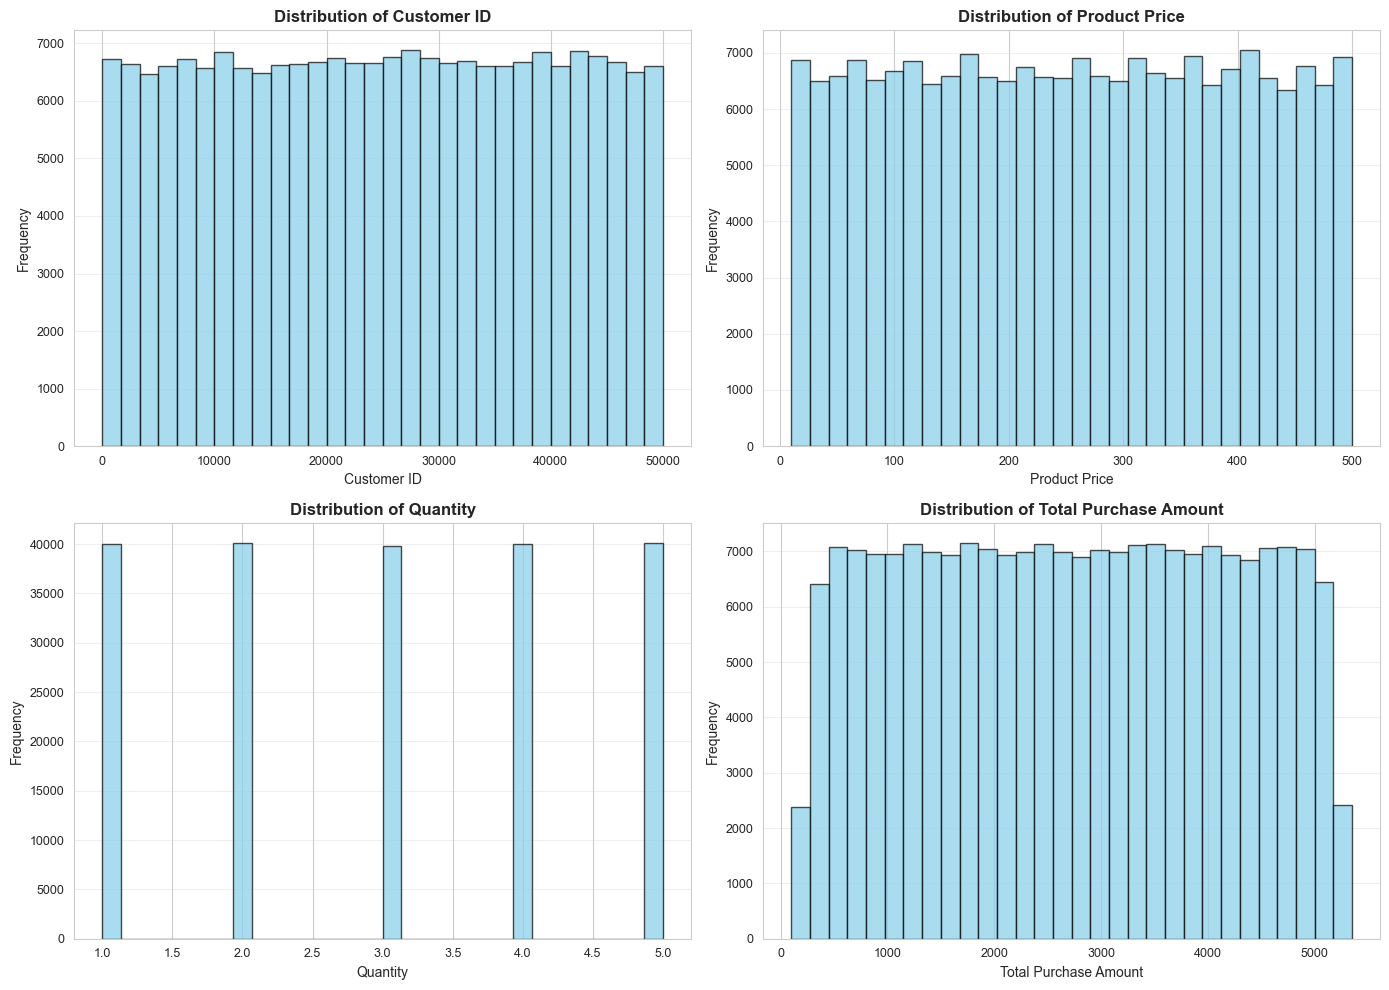

✓ Plotted 4 numerical features

--------------------------------------------------------------------------------
Visualizing Categorical Features Distribution
--------------------------------------------------------------------------------
⚠️  Skipping 'Purchase Date' - too many unique values (199968) > 30
⚠️  Skipping 'Customer Name' - too many unique values (32904) > 30


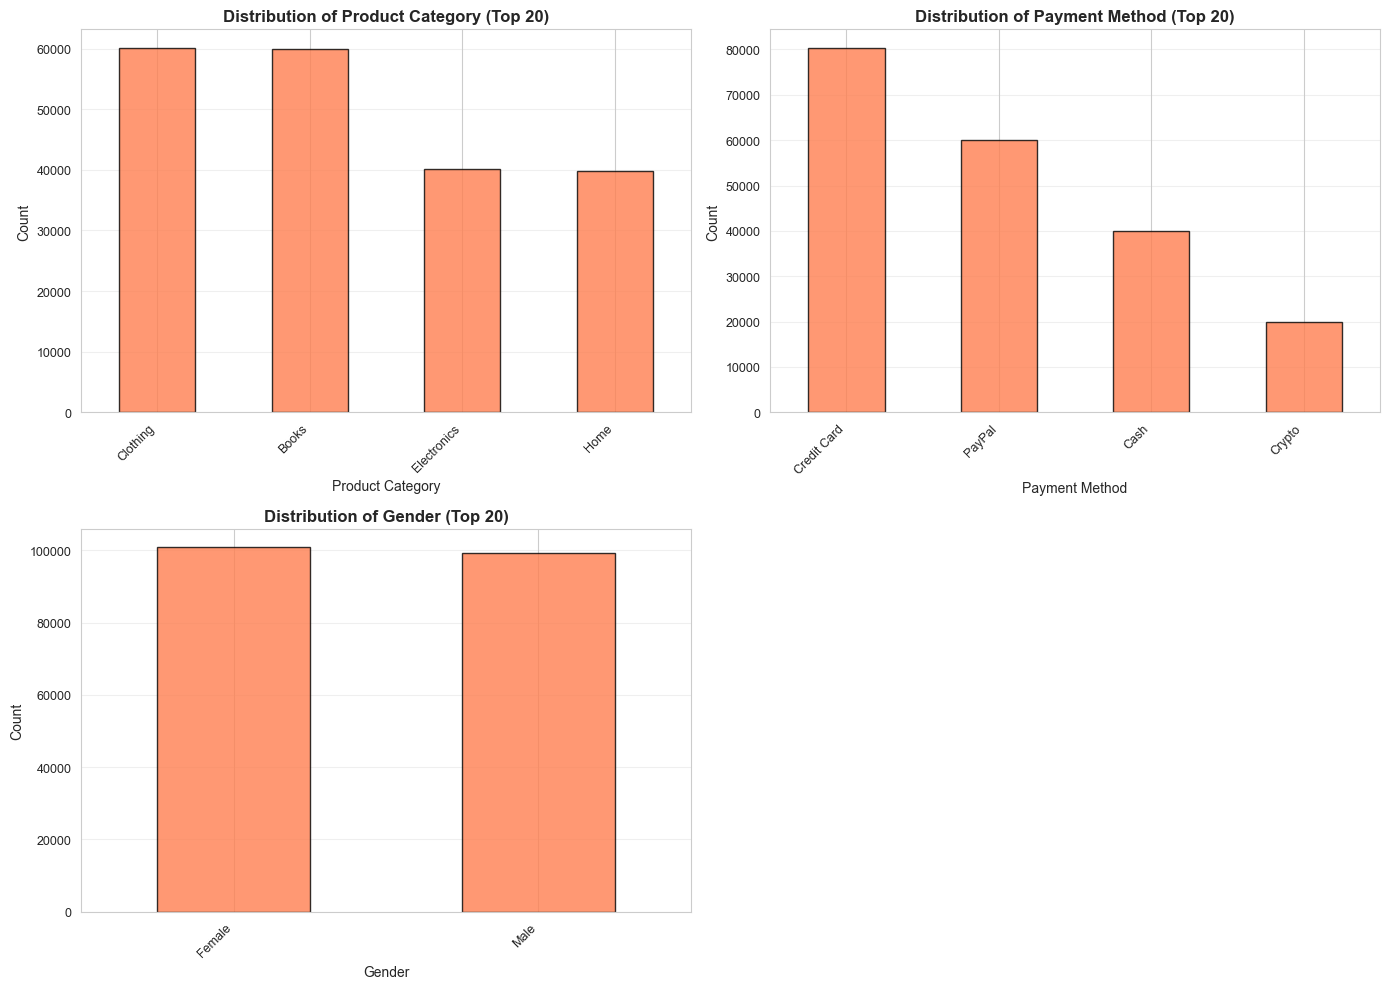

✓ Plotted 3 categorical features safely

--------------------------------------------------------------------------------
Correlation Analysis
--------------------------------------------------------------------------------
                       Customer ID  Product Price  Quantity  \
Customer ID               1.000000       0.004466 -0.001514   
Product Price             0.004466       1.000000 -0.000304   
Quantity                 -0.001514      -0.000304  1.000000   
Total Purchase Amount     0.001418      -0.004341  0.001021   
Customer Age              0.003596      -0.003646  0.000062   
Returns                   0.001421      -0.002764  0.000056   
Age                       0.003596      -0.003646  0.000062   
Churn                          NaN            NaN       NaN   

                       Total Purchase Amount  Customer Age   Returns  \
Customer ID                         0.001418      0.003596  0.001421   
Product Price                      -0.004341     -0.003646 -0.00

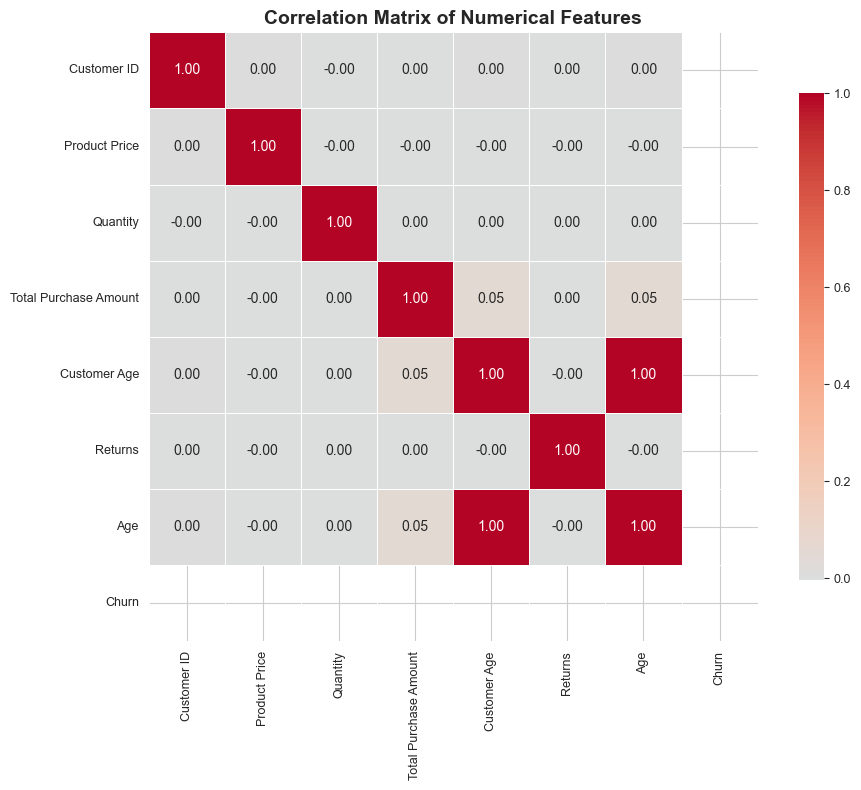


--------------------------------------------------------------------------------
Strong Correlations (|r| > 0.7)
--------------------------------------------------------------------------------
  • Customer Age ↔ Age: 1.0000

--------------------------------------------------------------------------------
Outliers Analysis - Box Plots
--------------------------------------------------------------------------------


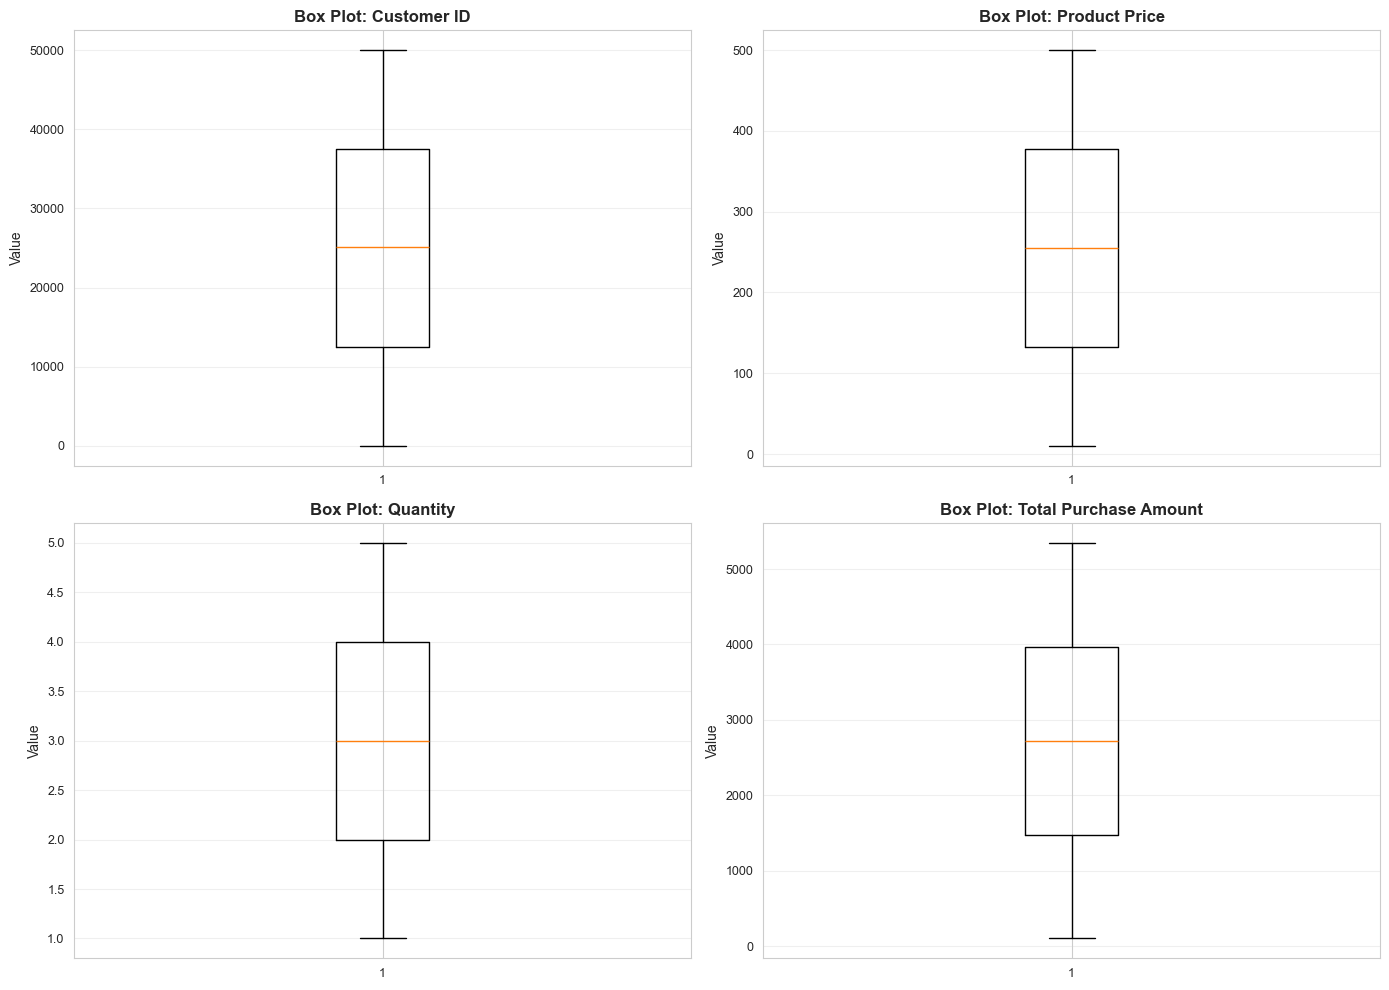

✓ Box plots generated for 4 numerical features

--------------------------------------------------------------------------------
Skewness & Kurtosis Analysis
--------------------------------------------------------------------------------
              Feature  Skewness  Kurtosis
          Customer ID -0.006545 -1.196894
        Product Price -0.000270 -1.198648
             Quantity  0.000053 -1.302108
Total Purchase Amount  0.000503 -1.192715
         Customer Age  0.004028 -1.203157
              Returns  0.396635 -1.842699
                  Age  0.004028 -1.203157
                Churn  0.000000  0.000000

Interpretation:
  • Skewness: -0.5 to 0.5 (Normal), > 0.5 (Right-skewed), < -0.5 (Left-skewed)
  • Kurtosis: ~3 (Normal), > 3 (Heavy-tailed), < 3 (Light-tailed)

EDA COMPLETE
✓ Exploratory Data Analysis completed successfully
✓ Ready for Association Rule Mining


In [29]:
print_section_header("STEP 3: EXPLORATORY DATA ANALYSIS (EDA)")

perform_eda(df_cleaned)

In [30]:
# Reload the association_rule_mining module to get latest changes
import importlib
import association_rule_mining
importlib.reload(association_rule_mining)
from association_rule_mining import perform_association_rule_mining
print("✓ Module reloaded")

✓ Module reloaded



STEP 4: ASSOCIATION RULE MINING

ASSOCIATION RULE MINING
⚡ Large dataset detected (200,126 rows). Sampling 50% for faster ARM...
   Using 100,063 rows for analysis


--------------------------------------------------------------------------------
Creating Customer-Level RFM Features
--------------------------------------------------------------------------------
Available columns in input data: ['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']
Successfully created customer-level dataset: 36779 unique customers
Columns: ['Customer ID', 'Recency', 'Purchase_Frequency', 'Monetary_Value', 'Customer_Age', 'Age', 'Gender', 'Churn', 'Total_Returns', 'Category_Preference', 'Preferred_Payment']
Customer-level records: 36,779

--------------------------------------------------------------------------------
Preparing Binary Data for Association Rules (B

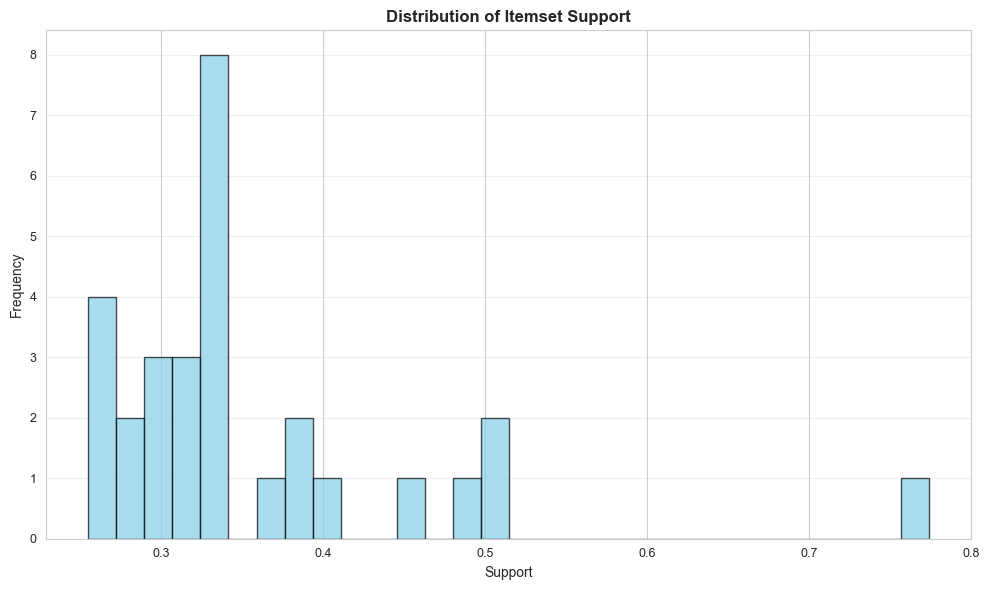


--------------------------------------------------------------------------------
Generating Association Rules
--------------------------------------------------------------------------------
Total Rules Generated: 12
Minimum Confidence: 0.6
Minimum Lift: 1.3
Rules after Lift filter: 2

--------------------------------------------------------------------------------
Association Rules Analysis
--------------------------------------------------------------------------------

Total Rules: 2

Support Statistics:
  Mean: 0.3090
  Min: 0.3090
  Max: 0.3090

Confidence Statistics:
  Mean: 0.7701
  Min: 0.6133
  Max: 0.9269

Lift Statistics:
  Mean: 1.8394
  Min: 1.8394
  Max: 1.8394

--------------------------------------------------------------------------------
Top 5 Rules by Lift
--------------------------------------------------------------------------------

  1. frozenset({'Freq_Low'}) → frozenset({'Spend_Low'})
     Support: 0.3090, Confidence: 0.6133, Lift: 1.8394

  2. frozenset({'Sp

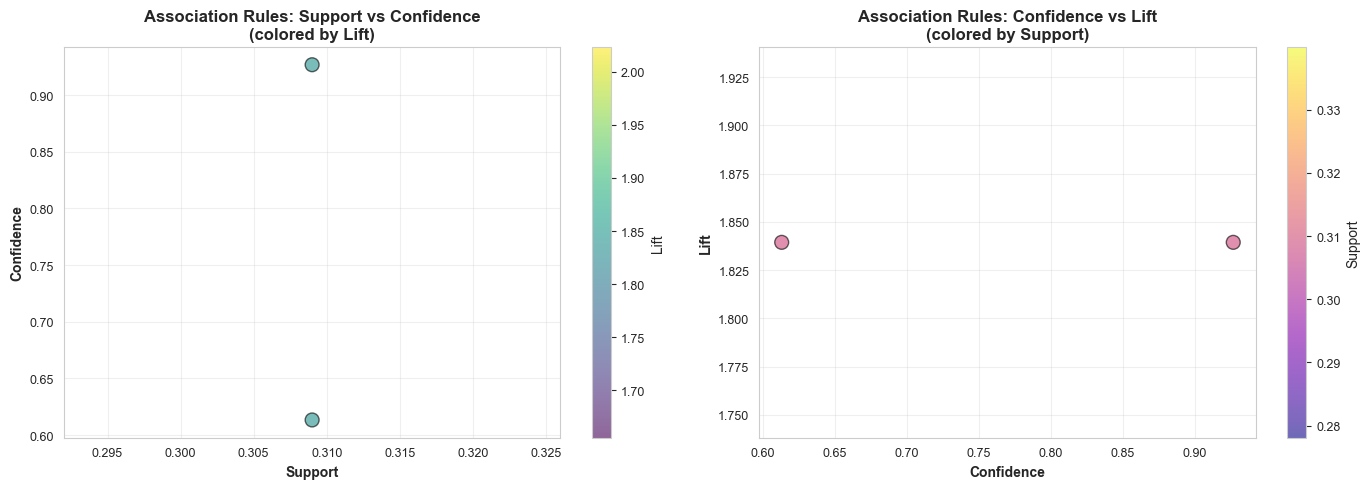

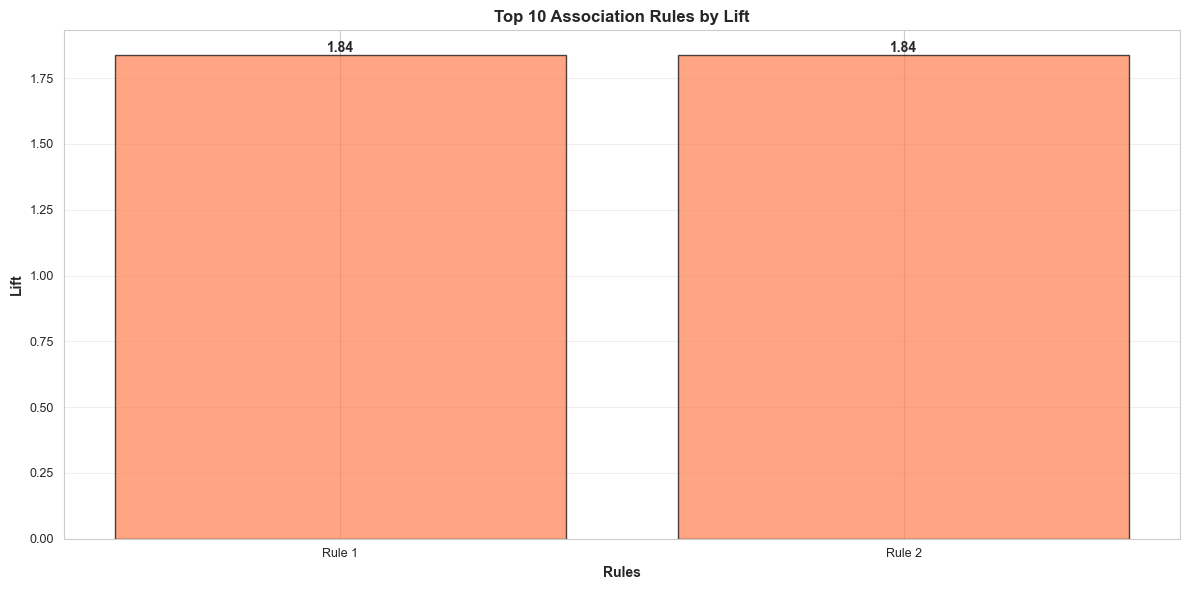


ASSOCIATION RULE MINING COMPLETE
✓ Frequent Itemsets: 29
✓ Association Rules: 2
✓ Ready for Classification Models


In [31]:
print_section_header("STEP 4: ASSOCIATION RULE MINING")

frequent_itemsets, rules = perform_association_rule_mining(df_cleaned)


STEP 5: CLASSIFICATION MODELS

CLASSIFICATION MODELS

--------------------------------------------------------------------------------
Preparing Data for Classification
--------------------------------------------------------------------------------
Target Variable Created: High vs Low based on Customer ID
  Threshold: 37554.00

Class Distribution:
  Class 0 (Low): 150098 (75.0%)
  Class 1 (High): 50028 (25.0%)

Encoding Categorical Features:
  ✓ Purchase Date: encoded
  ✓ Product Category: encoded
  ✓ Payment Method: encoded
  ✓ Customer Name: encoded
  ✓ Gender: encoded

Features Shape: (200126, 13)
Target Shape: (200126,)

--------------------------------------------------------------------------------
Splitting and Scaling Data
--------------------------------------------------------------------------------
Training Set Size: 140088 (70.0%)
Test Set Size: 60038 (30.0%)

✓ Data scaled using StandardScaler
  Mean of scaled training features ≈ 0: ✓
  Std Dev of scaled training featur

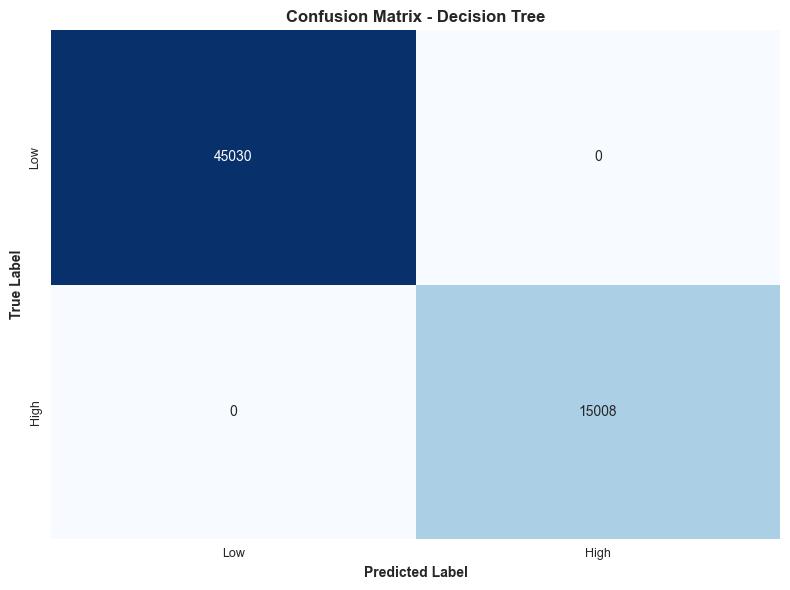

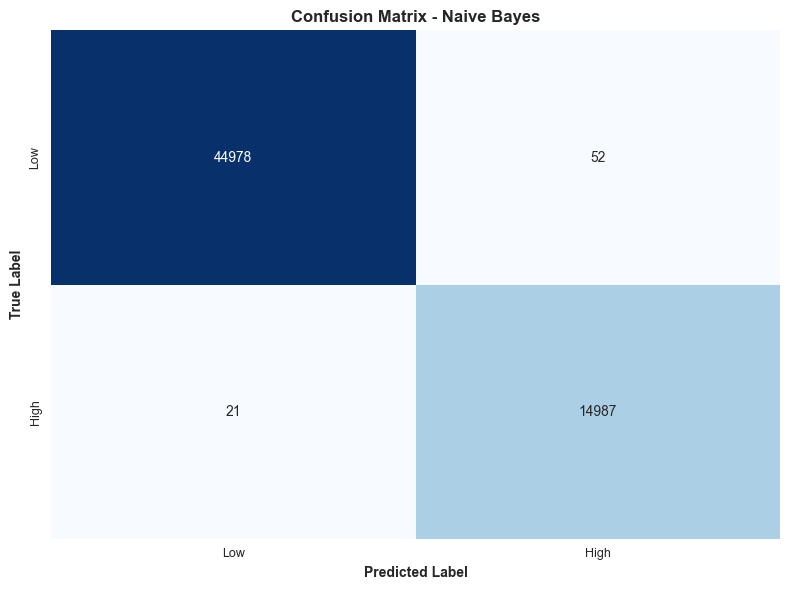

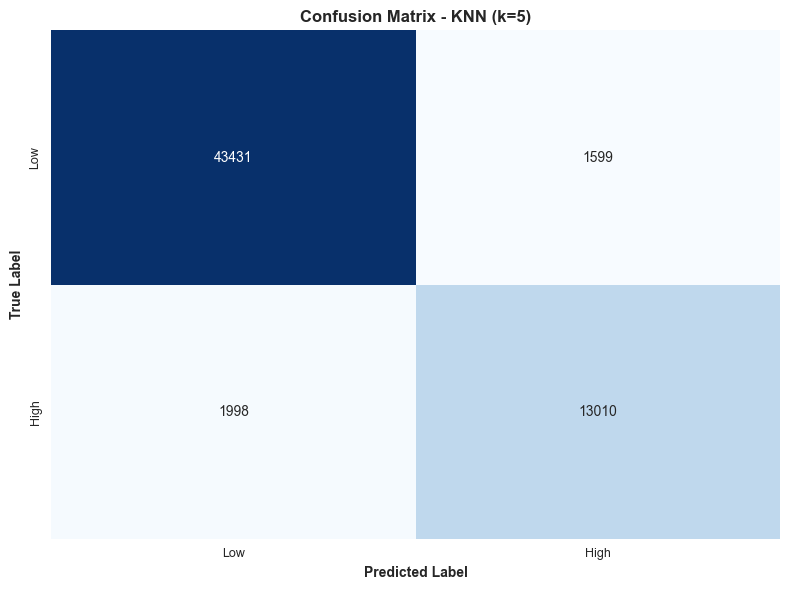


MODEL COMPARISON

--------------------------------------------------------------------------------
Model Comparison & Ranking
--------------------------------------------------------------------------------

Performance Comparison Table:
               accuracy  precision  recall      f1
Decision Tree    1.0000     1.0000  1.0000  1.0000
Naive Bayes      0.9988     0.9965  0.9986  0.9976
KNN (k=5)        0.9401     0.8905  0.8669  0.8785


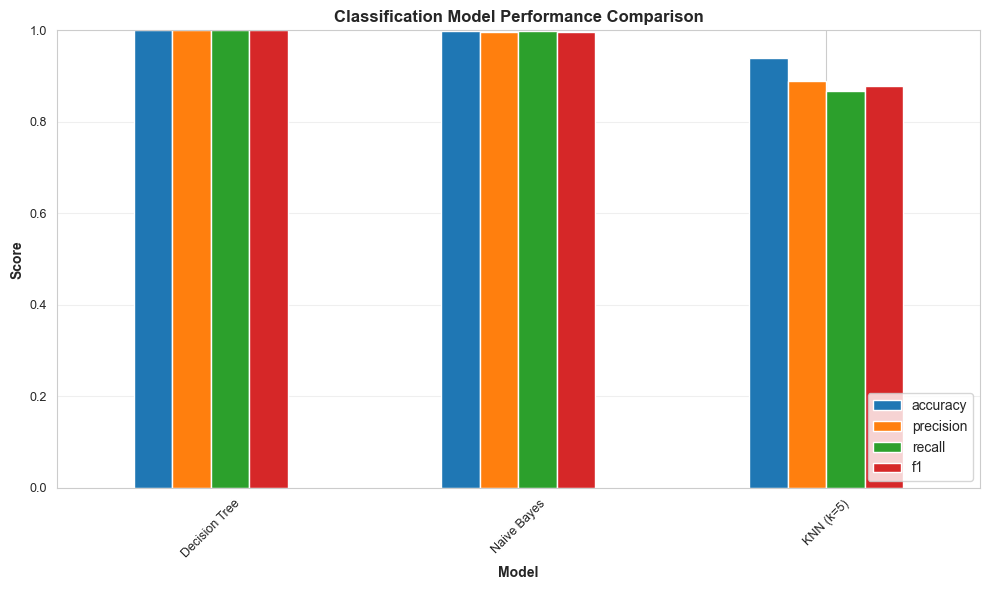


Model Ranking (by F1-Score):
  1. Decision Tree: 1.0000
  2. Naive Bayes: 0.9976
  3. KNN (k=5): 0.8785

🏆 Best Model: Decision Tree (F1-Score: 1.0000)

CLASSIFICATION COMPLETE
✓ Models trained: 3
✓ Best model: Decision Tree
✓ Ready for Clustering & Customer Segmentation


In [32]:
print_section_header("STEP 5: CLASSIFICATION MODELS")

classification_result = perform_classification(df_cleaned)

In [ ]:
print_section_header("STEP 6: CLUSTERING & CUSTOMER SEGMENTATION")

clustering_result = perform_clustering(df_cleaned)


STEP 6: CLUSTERING & CUSTOMER SEGMENTATION

CLUSTERING & CUSTOMER SEGMENTATION

--------------------------------------------------------------------------------
Preparing Data for Clustering
--------------------------------------------------------------------------------
Encoding Categorical Features: 5
  ✓ Purchase Date: encoded
  ✓ Product Category: encoded
  ✓ Payment Method: encoded
  ✓ Customer Name: encoded
  ✓ Gender: encoded

Features for Clustering: 13
Samples for Clustering: 200126

✓ Features standardized using StandardScaler

--------------------------------------------------------------------------------
Finding Optimal Number of Clusters
--------------------------------------------------------------------------------
Testing K values: [2, 3, 4, 5, 6, 7, 8, 9]

K=2: Inertia=2100665.28, Silhouette=0.1170
K=3: Inertia=1990708.41, Silhouette=0.0902


In [ ]:
print_section_header("STEP 7: BUSINESS INSIGHTS")

print("\n📌 Association Rule Insights:")
association_rule_insights(rules)

print("\n📌 Classification Insights:")
classification_insights(classification_result)

print("\n📌 Clustering Insights:")
clustering_insights(clustering_result, df_cleaned)

In [ ]:
print_section_header("STEP 8: COMPREHENSIVE PROJECT SUMMARY")

generate_summary_report(df_raw, preprocessing_result, classification_result, 
                       clustering_result, frequent_itemsets, rules)

In [ ]:
challenges_and_learnings()

In [ ]:
team_contribution_table()

In [ ]:
tools_and_libraries()

In [ ]:
print_section_header("PROJECT COMPLETION SUMMARY")

summary_data = {
    'Metric': [
        'Initial Records',
        'Final Records',
        'Records Removed',
        'Total Features',
        'Numerical Features',
        'Categorical Features',
        'Frequent Itemsets',
        'Association Rules',
        'Classification Models',
        'Optimal Clusters',
        'Project Status'
    ],
    'Value': [
        f"{df_raw.shape[0]}",
        f"{df_cleaned.shape[0]}",
        f"{df_raw.shape[0] - df_cleaned.shape[0]}",
        f"{df_cleaned.shape[1]}",
        f"{len(preprocessing_result['numerical_cols'])}",
        f"{len(preprocessing_result['categorical_cols'])}",
        f"{len(frequent_itemsets) if frequent_itemsets is not None else 'N/A'}",
        f"{len(rules) if rules is not None else 'N/A'}",
        f"{len(classification_result['results']) if classification_result else 'N/A'}",
        f"{clustering_result['optimal_k'] if clustering_result else 'N/A'}",
        "✅ COMPLETED"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"""
{'='*80}
🎉 PROJECT SUCCESSFULLY COMPLETED 🎉
{'='*80}

✅ All analytical phases completed:
   • Data Loading & Exploration
   • Data Preprocessing & Cleaning
   • Exploratory Data Analysis
   • Association Rule Mining
   • Classification Modeling
   • Clustering & Segmentation
   • Business Insights Generation

📊 Key Deliverables:
   • Cleaned and processed dataset
   • Multiple visualization sets
   • Trained classification models
   • Customer segments identified
   • Association rules extracted
   • Actionable business recommendations

📝 Next Steps:
   1. Generate formal project report (PDF)
   2. Create presentation slides with key findings
   3. Prepare viva responses based on analysis
   4. Document all assumptions and decisions
   5. Archive code and results

{'='*80}
Project completed on: {pd.Timestamp.now()}
{'='*80}
""")